
# HỆ THỐNG ĐỀ XUẤT SẢN PHẨM TRONG THƯƠNG MẠI ĐIỆN TỬ

Hệ thống này giúp nâng cao trải nghiệm người dùng thông qua việc gợi ý sản phẩm phù hợp với sở thích cá nhân. Ngoài ra, nó đóng vai trò quan trọng trong việc tăng doanh thu và hiệu quả kinh doanh cho doanh nghiệp. Việc nghiên cứu đề tài này còn tạo cơ hội áp dụng các thuật toán tiên tiến trong AI và học máy vào thực tế. Hệ thống đề xuất sản phẩm là xu hướng tất yếu trong thời đại phát triển mạnh mẽ của thương mại điện tử. Cuối cùng, đề tài góp phần thúc đẩy các giải pháp công nghệ bền vững và tối ưu hóa quy trình mua sắm.

## Hệ thống đề xuất sản phẩm cho các doanh nghiệp thương mại điện tử là gì?

-Là các công cụ phần mềm cung cấp các đề xuất về sản phẩm hoặc nội dung được cá nhân hóa cho người dùng dựa trên hành vi và sở thích của họ.
Chúng cực kỳ có giá trị trong thương mại điện tử vì chúng giúp chuyển đổi trình duyệt thành người mua, tăng giá trị đơn hàng trung bình
và cải thiện lòng trung thành của khách hàng thông qua các trải nghiệm được thiết kế riêng.

-Có ba loại hệ thống đề xuất:

- Hệ thống đề xuất dựa trên nội dung: Loại hệ thống đề xuất này phân tích các thông số khác nhau của sản phẩm (tên sản phẩm, thương hiệu, giá, mô tả, tính năng). Hệ thống này lấy tên sản phẩm làm đầu vào và trả về tất cả các sản phẩm tương tự dựa trên các thông số này.
  
- Hệ thống đề xuất dựa trên người dùng: Đây còn được gọi là lọc cộng tác. Hệ thống này xem xét dữ liệu nhân khẩu học, hoạt động và sở thích của người dùng. Nếu người A và người B có hồ sơ tương tự (tuổi, sở thích, hoạt động, v.v.) và người A thích một sản phẩm cụ thể hoặc đã xem một sản phẩm cụ thể, thì hệ thống đề xuất sẽ đề xuất người B những sản phẩm mà người A đã xem và ngược lại.
  
- Hệ thống đề xuất dựa trên mức độ phổ biến: Hệ thống này theo dõi lượt xem, lượt thích và sản phẩm đã mua và đề xuất những sản phẩm phổ biến trong khu vực đó bằng cách phân tích các thông số này.

-Thông qua việc đề xuất sản phẩm, hệ thống có thể cá nhân hóa trải nghiệm người dùng, tăng mức độ tương tác và giữ chân, đồng thời cuối cùng thúc đẩy doanh số bán hàng cao hơn.

## Xây dựng và triển khai mô hình

### Importing libraries:

In [ ]:
import pandas as pd
import warnings

warnings.filterwarnings("ignore")


# ==============================
# PREPROCESSING
# ==============================

from src.preprocessing import (
    clean_data
)


# ==============================
# EDA
# ==============================

from src.eda import (
    plot_missing_values,
    plot_rating_distribution,
    plot_price_distribution,
    plot_top_departments,
    plot_top_brands,
    plot_price_vs_rating
)


# ==============================
# FEATURE ENGINEERING
# ==============================

from src.feature_engineering import (
    create_combined_features,
    create_similarity_matrix,
    create_indices
)


# ==============================
# POPULARITY MODEL
# ==============================

from src.popularity_model import (
    get_popular_products,
    evaluate_popularity
)


# ==============================
# CONTENT-BASED MODEL
# ==============================

from src.content_based_model import (
    recommend_products,
    precision_at_k
)


# ==============================
# COLLABORATIVE FILTERING
# ==============================

from src.collaborative_model import (
    simulate_user_interactions,
    create_user_item_matrix,
    train_knn_model,
    find_similar_users,
    evaluate_collaborative
)


# ==============================
# HYBRID MODEL
# ==============================

from src.hybrid_model import (
    hybrid_recommendation
)

### Import the Dataset:


Sử dụng dữ liệu đã công khai trên Amazon vào năm 2020.

https://brightdata.com/cp/datasets/browse/gd_l7q7dkf244hwjntr0?id=hl_67a497d9&tab=sam

In [ ]:
df = pd.read_csv("Amazon_products.csv",encoding='ISO-8859-1')

## 🧾 Giải nghĩa các thuộc tính trong dataset

### 🔹 Thông tin sản phẩm

- **title**: Tên sản phẩm  
- **brand**: Thương hiệu của sản phẩm  
- **description**: Mô tả chi tiết hoặc giới thiệu sản phẩm  
- **categories**: Danh mục sản phẩm (có thể gồm nhiều cấp, phân tách bằng ký tự `|`)  
- **department**: Ngành hàng mà sản phẩm thuộc về  

---

### 💰 Thông tin giá

- **initial_price**: Giá gốc ban đầu của sản phẩm trước khi giảm giá  
- **final_price**: Giá bán hiện tại của sản phẩm sau khi áp dụng khuyến mãi  
- **discount**: Thông tin giảm giá của sản phẩm (thường ở dạng phần trăm hoặc text, cần xử lý thêm)  
- **currency**: Đơn vị tiền tệ của giá sản phẩm  

---

### ⭐ Đánh giá sản phẩm

- **rating**: Điểm đánh giá trung bình của sản phẩm (thường trong khoảng từ 0 đến 5)  
- **root_bs_rank**: Thứ hạng Best Seller của sản phẩm (giá trị càng nhỏ thì sản phẩm càng bán chạy)  

---

### 🔗 Thông tin định danh & liên kết

- **asin**: Mã định danh duy nhất của sản phẩm trên Amazon  
- **url**: Đường dẫn trực tiếp đến trang sản phẩm  

---

### ⚙️ Thông tin bổ sung

- **model_number**: Mã model hoặc số hiệu sản phẩm do nhà sản xuất cung cấp  
- **availability**: Trạng thái sản phẩm (còn hàng hoặc hết hàng)

CLEAN DATA

In [ ]:
df = clean_data(df)

# **EDA**

# Missing Values Analysis

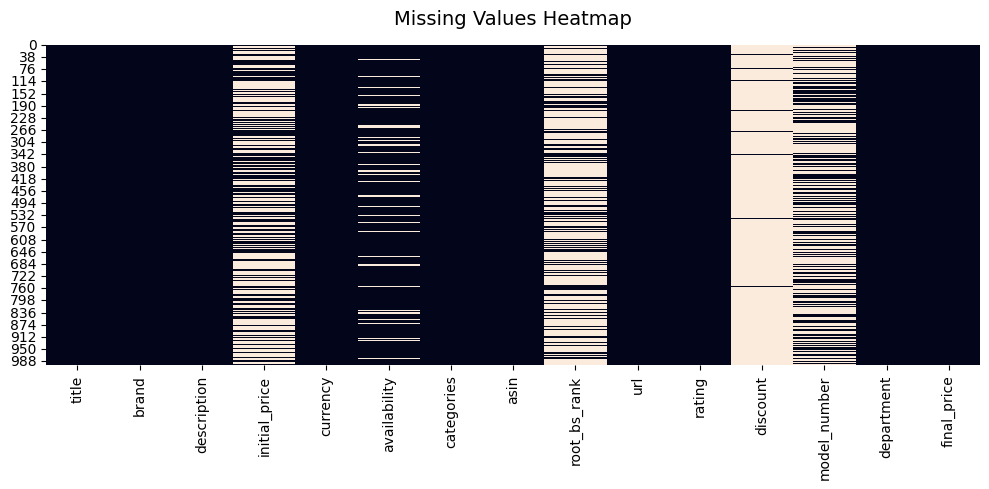

In [ ]:
plot_missing_values(df)

### Phân tích:

Biểu đồ heatmap cho thấy bộ dữ liệu vẫn tồn tại một số giá trị thiếu (missing values) ở nhiều thuộc tính khác nhau.

- Các cột như `title`, `brand`, `description`, `categories`, `asin`, `rating`, `department` và `final_price` hầu như đầy đủ dữ liệu.
- Cột `initial_price` chứa khá nhiều giá trị thiếu, cho thấy không phải tất cả sản phẩm đều có thông tin giá gốc ban đầu.
- `root_bs_rank` và `model_number` cũng có số lượng missing values lớn, phản ánh việc nhiều sản phẩm không có thông tin xếp hạng bán chạy hoặc mã sản phẩm.
- Cột `discount` có tỷ lệ thiếu dữ liệu rất cao do phần lớn sản phẩm không có thông tin giảm giá.

Các giá trị thiếu này đã được xử lý trong bước preprocessing bằng cách:
- Điền giá trị mặc định cho dữ liệu dạng text.
- Điền giá trị trung bình/trung vị cho dữ liệu số.
- Chuyển đổi kiểu dữ liệu phù hợp trước khi xây dựng hệ thống đề xuất.

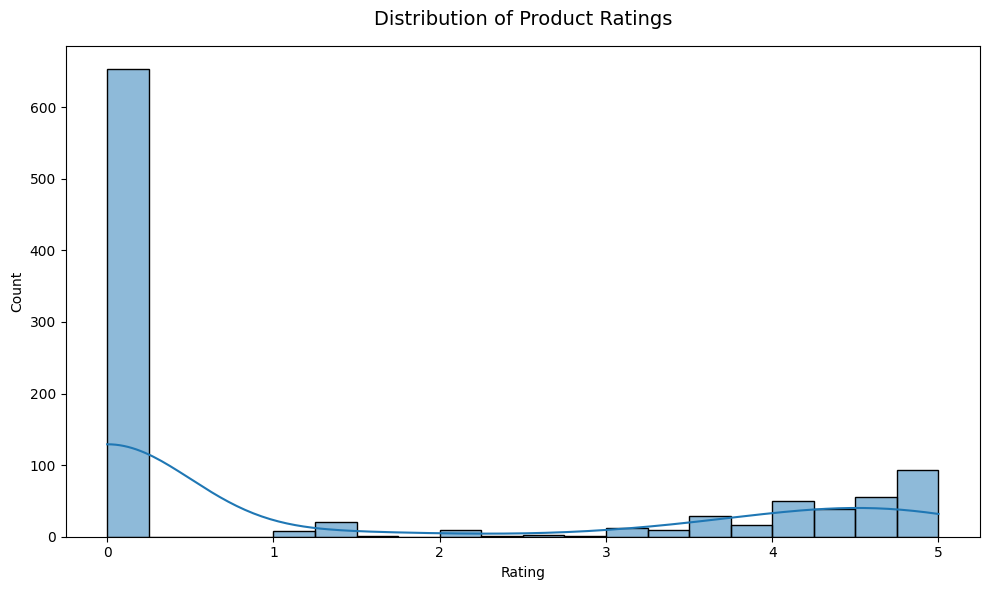

In [ ]:
plot_rating_distribution(df)

### Phân tích:

Biểu đồ phân phối rating cho thấy dữ liệu bị lệch khá mạnh về phía các giá trị thấp và giá trị cao.

- Một lượng lớn sản phẩm có rating bằng 0 hoặc gần 0, cho thấy nhiều sản phẩm chưa có đánh giá từ người dùng hoặc dữ liệu rating bị thiếu trước khi xử lý.
- Ngoài nhóm rating bằng 0, phần lớn sản phẩm còn lại tập trung trong khoảng từ 4.0 đến 5.0.
- Điều này phản ánh xu hướng phổ biến trên các sàn thương mại điện tử khi các sản phẩm thường nhận được đánh giá tích cực từ người dùng.
- Phân phối dữ liệu không cân bằng có thể ảnh hưởng đến chất lượng hệ thống đề xuất, đặc biệt đối với collaborative filtering, vì các sản phẩm có ít đánh giá sẽ khó được học đầy đủ hành vi người dùng.

Từ biểu đồ có thể thấy rating là một thuộc tính quan trọng và có thể được sử dụng hiệu quả trong các phương pháp recommendation như popularity-based recommendation và collaborative filtering.

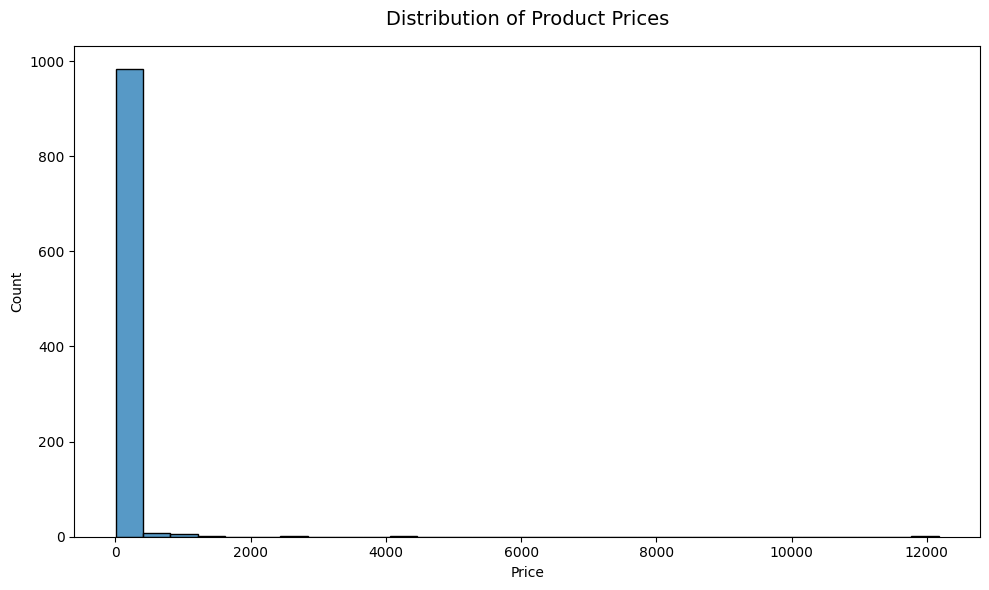

In [ ]:
plot_price_distribution(df)

### Phân tích:

Biểu đồ phân phối giá sản phẩm cho thấy dữ liệu bị lệch phải (right-skewed distribution).

- Phần lớn sản phẩm có mức giá thấp và tập trung gần khu vực giá trị nhỏ.
- Chỉ có một số ít sản phẩm có giá rất cao, tạo nên các outliers kéo dài về phía bên phải biểu đồ.
- Khoảng giá sản phẩm khá rộng, dao động từ các sản phẩm giá rẻ đến các sản phẩm có giá trị lớn.

Điều này phản ánh đặc điểm phổ biến của các nền tảng thương mại điện tử khi số lượng sản phẩm giá phổ thông thường chiếm đa số, trong khi các sản phẩm cao cấp xuất hiện với số lượng ít hơn.

Phân phối giá không đồng đều có thể ảnh hưởng đến hệ thống recommendation nếu sử dụng trực tiếp thuộc tính giá. Vì vậy, trong bước feature engineering, giá sản phẩm có thể được chuẩn hóa hoặc kết hợp cùng các đặc trưng khác để cải thiện chất lượng gợi ý sản phẩm.

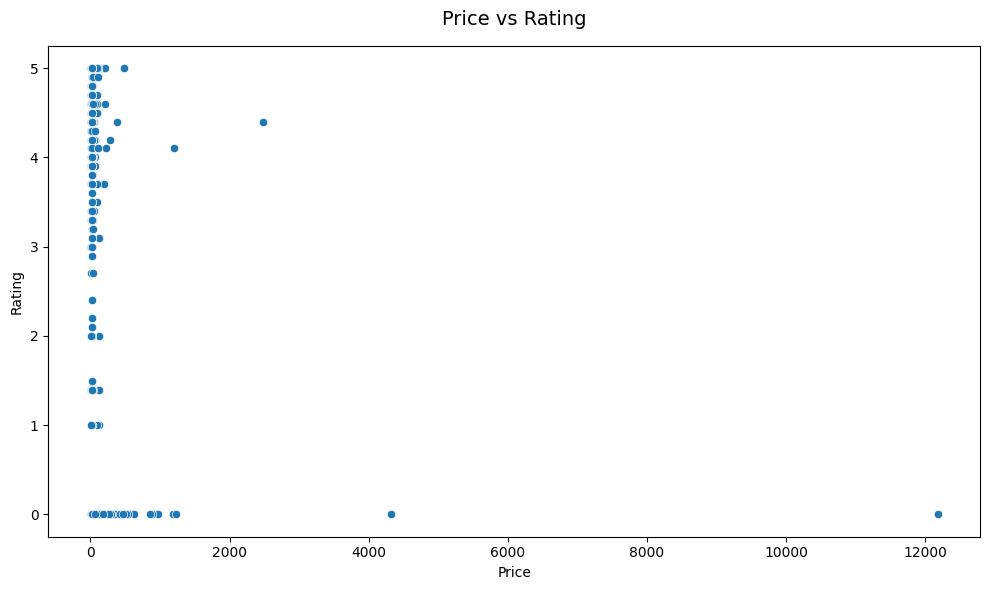

In [ ]:
plot_price_vs_rating(df)

### Phân tích:

Biểu đồ scatterplot cho thấy mối quan hệ giữa giá sản phẩm (`final_price`) và rating tương đối yếu.

- Phần lớn sản phẩm tập trung ở mức giá thấp nhưng vẫn nhận được nhiều mức rating khác nhau, chủ yếu từ 3 đến 5 sao.
- Các sản phẩm có rating cao không chỉ xuất hiện ở nhóm giá cao mà còn xuất hiện nhiều ở nhóm giá thấp, cho thấy giá sản phẩm không phải yếu tố quyết định trực tiếp đến mức độ hài lòng của người dùng.
- Xuất hiện một số outliers với mức giá rất cao nhưng rating bằng 0 hoặc thấp, điều này có thể do sản phẩm chưa có đánh giá hoặc có rất ít lượt đánh giá từ người dùng.
- Dữ liệu phân bố khá phân tán và không hình thành xu hướng tuyến tính rõ ràng giữa giá và rating.

Từ biểu đồ có thể thấy rằng việc xây dựng hệ thống recommendation không nên chỉ dựa vào giá sản phẩm mà cần kết hợp thêm nhiều thuộc tính khác như mô tả, thương hiệu, danh mục và lịch sử tương tác để tăng chất lượng đề xuất.

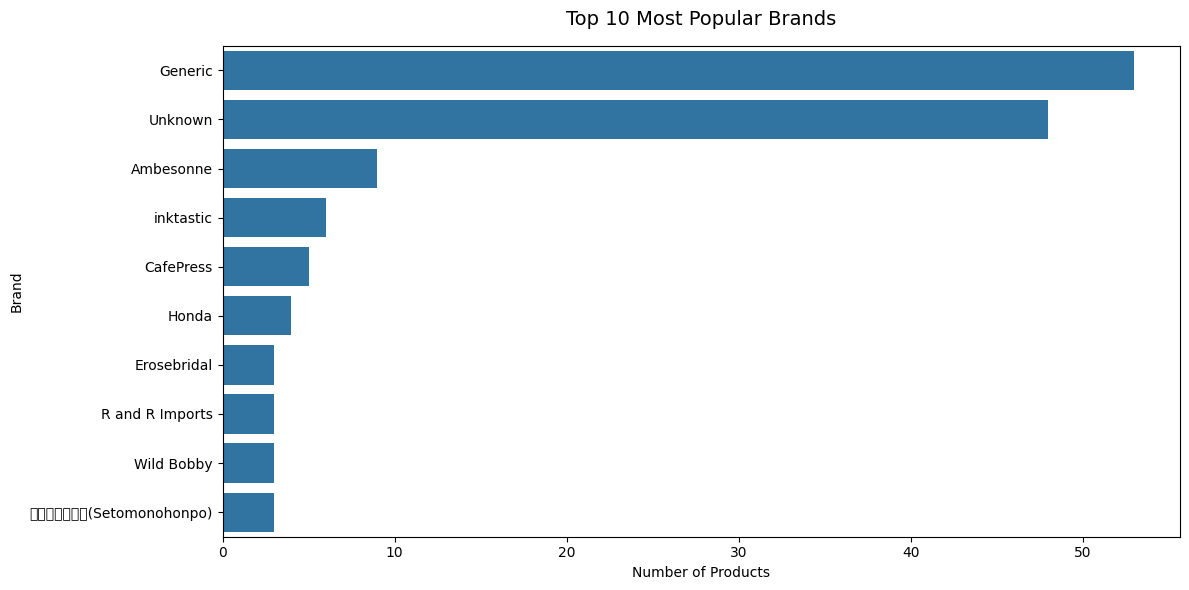

In [ ]:
plot_top_brands(df)

### Phân tích:

Biểu đồ cho thấy sự phân bố số lượng sản phẩm theo thương hiệu trong bộ dữ liệu.

- Hai nhóm thương hiệu `Generic` và `Unknown` chiếm số lượng sản phẩm lớn nhất, vượt xa các thương hiệu còn lại.
- Điều này cho thấy nhiều sản phẩm trong dataset không có thông tin thương hiệu đầy đủ hoặc sử dụng tên thương hiệu chung.
- Các thương hiệu còn lại như `Ambesonne`, `inktastic`, `CafePress` hay `Honda` xuất hiện với số lượng ít hơn đáng kể.
- Sự phân bố thương hiệu không đồng đều phản ánh đặc điểm phổ biến của dữ liệu thương mại điện tử, nơi một số thương hiệu hoặc nhà bán hàng chiếm phần lớn số lượng sản phẩm.

Kết quả này cho thấy thuộc tính `brand` có thể hữu ích trong hệ thống recommendation, đặc biệt đối với content-based recommendation khi người dùng thường có xu hướng quan tâm đến các thương hiệu quen thuộc.

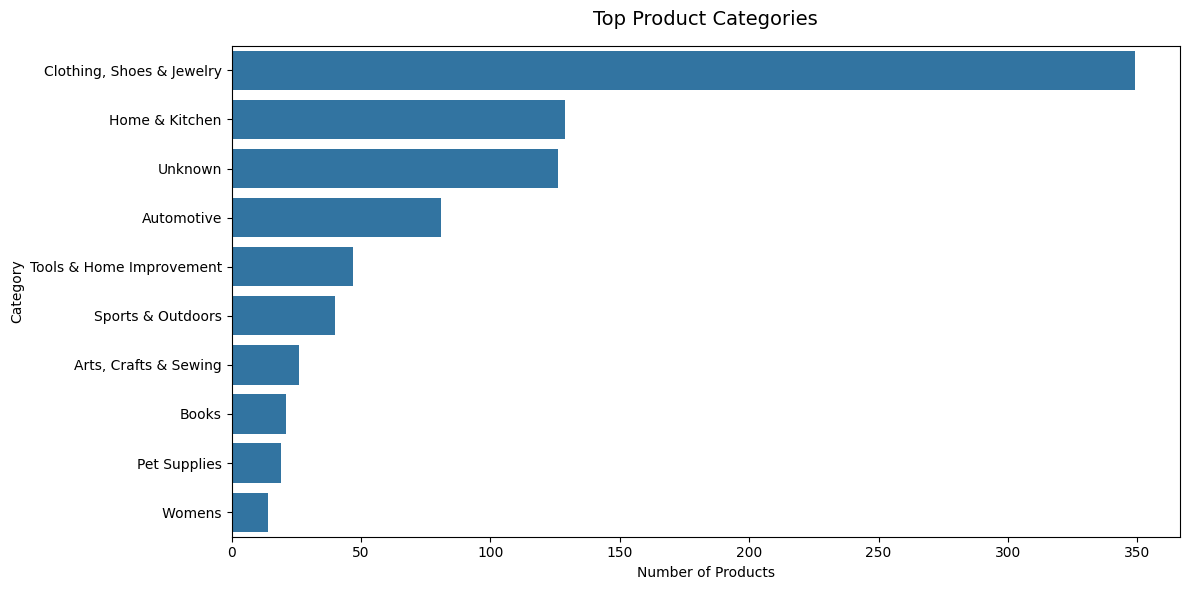

In [ ]:
plot_top_departments(df)

### Phân tích:

Biểu đồ cho thấy sự phân bố số lượng sản phẩm theo từng ngành hàng (`department`) trong bộ dữ liệu.

- Ngành hàng `Clothing, Shoes & Jewelry` chiếm số lượng sản phẩm lớn nhất, vượt trội so với các nhóm còn lại.
- Các nhóm như `Home & Kitchen` và `Unknown` cũng có số lượng sản phẩm khá cao, cho thấy đây là những danh mục phổ biến trong dữ liệu thương mại điện tử.
- Một số ngành hàng như `Books`, `Pet Supplies` và `Womens` xuất hiện với số lượng sản phẩm thấp hơn đáng kể.
- Dữ liệu phân bố không đồng đều giữa các danh mục sản phẩm, phản ánh thực tế rằng một số ngành hàng trên các sàn thương mại điện tử thường có lượng sản phẩm đa dạng hơn nhiều so với các nhóm khác.

Kết quả này có thể hỗ trợ hệ thống recommendation trong việc xác định các danh mục phổ biến và cải thiện khả năng đề xuất sản phẩm theo sở thích hoặc hành vi người dùng.

In [ ]:
get_popular_products_by_department(df)

,asin,root_bs_rank,department
150,B081ZNHXZL,0.0,Boys
556,B06Y26MCTT,0.0,Boys
297,B0D3GHGXNY,83.0,Electronics
122,B0DZC2F18S,1060.0,Electronics
939,B07GJJJQZS,3450.0,Electronics
2,B0FR4GN6WZ,9427.0,Baby Products
61,B0FF492J6M,10379.0,Home & Kitchen
95,B0C62CL9RV,10940.0,Electronics
124,B01LYR28L8,15121.0,‏ ‎ Womens
875,B0CQF64RWR,18887.0,"Clothing, Shoes & Jewelry"


### Phân tích:

Bảng dữ liệu hiển thị các sản phẩm có `root_bs_rank` tốt nhất theo từng ngành hàng (`department`).

- Các sản phẩm được sắp xếp theo `root_bs_rank` tăng dần, trong đó giá trị càng nhỏ cho thấy sản phẩm có mức độ phổ biến hoặc doanh số bán hàng càng cao.
- Một số ngành hàng như `Electronics`, `Clothing, Shoes & Jewelry` và `Womens` xuất hiện nhiều lần trong danh sách, cho thấy đây là những nhóm sản phẩm có nhiều sản phẩm bán chạy.
- Một vài sản phẩm có `root_bs_rank` bằng 0, điều này có thể xuất phát từ dữ liệu thiếu hoặc lỗi trong quá trình crawl dữ liệu.
- Dữ liệu cũng cho thấy sự đa dạng giữa các ngành hàng với nhiều nhóm sản phẩm khác nhau xuất hiện trong top popular products.

Thông tin về thứ hạng bán chạy (root_bs_rank) có thể được sử dụng để xây dựng popularity-based recommendation, đặc biệt hiệu quả đối với người dùng mới chưa có lịch sử tương tác.

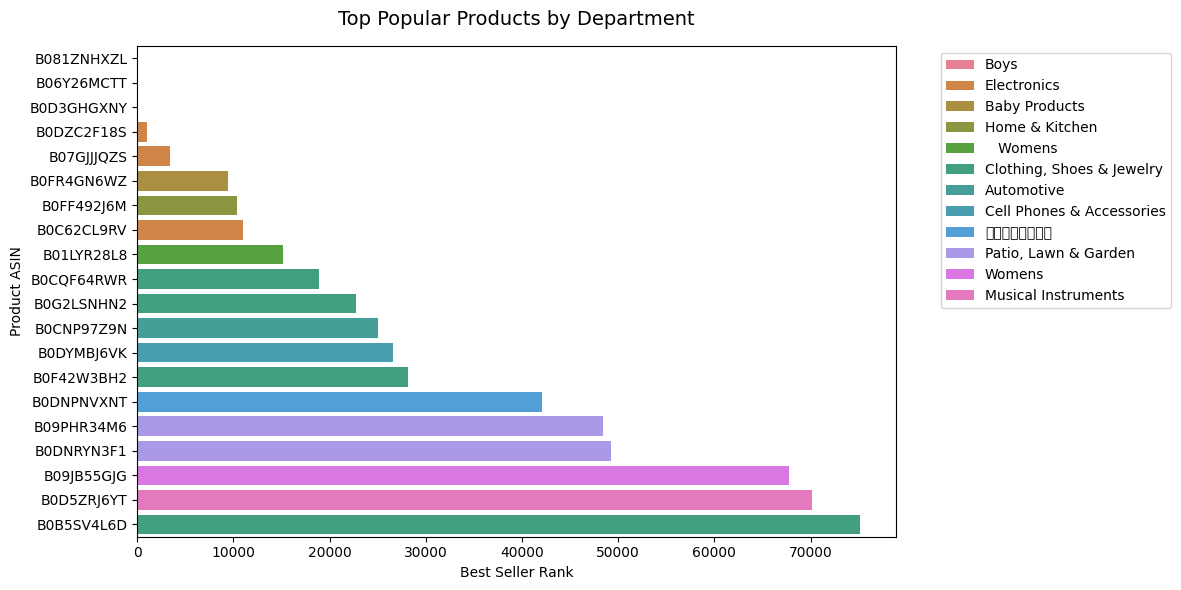

In [ ]:
plot_popular_products_by_department(df)

### Phân tích:

Biểu đồ thể hiện các sản phẩm có `root_bs_rank` tốt nhất theo từng ngành hàng (`department`).

- Các sản phẩm được sắp xếp theo `Best Seller Rank`, trong đó giá trị càng nhỏ cho thấy sản phẩm càng phổ biến hoặc có hiệu suất bán hàng tốt hơn.
- Một số ngành hàng như `Clothing, Shoes & Jewelry`, `Patio, Lawn & Garden` và `Womens` xuất hiện trong danh sách các sản phẩm có thứ hạng bán chạy tốt.
- Các sản phẩm thuộc nhóm `Electronics`, `Home & Kitchen` và `Automotive` cũng xuất hiện với mức `Best Seller Rank` tương đối tốt.
- Biểu đồ cho thấy sự khác biệt về thứ hạng bán chạy giữa các sản phẩm và ngành hàng.
- Các sản phẩm có Best Seller Rank nhỏ hơn thường nằm gần phía bên trái biểu đồ, thể hiện mức độ phổ biến cao hơn.

Thông tin này rất hữu ích cho hệ thống popularity-based recommendation vì có thể sử dụng `root_bs_rank` để xác định các sản phẩm nổi bật và ưu tiên đề xuất cho người dùng mới chưa có lịch sử tương tác.

### Hiển thị danh sách các tên cột trong Data Frame df_new

In [ ]:
# ==============================
# FEATURE ENGINEERING
# ==============================

df = create_combined_features(df)

df[
    ["title", "combined_features"]
].head()

,title,combined_features
0,Movie Posters A Bout De Souffle Room Decor Pos...,Movie Posters A Bout De Souffle Room Decor Pos...
1,Tiny Twinkle Splat Mat for Under High Chair or...,Tiny Twinkle Splat Mat for Under High Chair or...
2,Prince On Board Vinyl Decal Car Window Bumper ...,Prince On Board Vinyl Decal Car Window Bumper ...
3,McFarlane Toys Movie Maniacs - Fallout The Gho...,McFarlane Toys Movie Maniacs - Fallout The Gho...
4,TL Women's Solid Classic Lasting Everyday Pull...,TL Women's Solid Classic Lasting Everyday Pull...


### Phân tích:

Các thuộc tính văn bản quan trọng như tên sản phẩm, thương hiệu, mô tả, danh mục và ngành hàng được kết hợp thành một đặc trưng duy nhất (`combined_features`).

Việc kết hợp nhiều thuộc tính giúp hệ thống content-based recommendation khai thác đầy đủ thông tin mô tả sản phẩm khi tính toán độ tương đồng giữa các sản phẩm.

Ngoài ra, các dòng dữ liệu chứa quá ít thông tin đã được loại bỏ nhằm giảm nhiễu và cải thiện chất lượng recommendation.

In [ ]:
# ==============================
# TF-IDF VECTORIZATION
# ==============================

tfidf_matrix, cosine_sim = (
    create_similarity_matrix(df)
)

print("TF-IDF Matrix Shape:")
print(tfidf_matrix.shape)

TF-IDF Matrix Shape:
(963, 13990)


### Phân tích:

TF-IDF Vectorization được sử dụng để chuyển đổi dữ liệu văn bản thành dạng vector số.

Kết quả tạo ra ma trận thưa (sparse matrix), trong đó:
- mỗi dòng đại diện cho một sản phẩm
- mỗi cột đại diện cho một từ đặc trưng

Kích thước ma trận `(963, 13990)` cho thấy:
- bộ dữ liệu gồm 963 sản phẩm
- có khoảng 13,990 từ đặc trưng được trích xuất từ dữ liệu văn bản.

In [ ]:
# Convert sparse matrix to dataframe (preview)

tfidf_df = pd.DataFrame.sparse.from_spmatrix(
    tfidf_matrix
)

tfidf_df.head()

,0,1,2,3,4,5,6,7,8,9,...,13980,13981,13982,13983,13984,13985,13986,13987,13988,13989
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### Phân tích:

Ma trận TF-IDF có dạng sparse matrix với phần lớn giá trị bằng 0 do mỗi sản phẩm chỉ chứa một số lượng nhỏ từ khóa đặc trưng.

Việc sử dụng sparse matrix giúp tiết kiệm bộ nhớ và tăng hiệu quả tính toán khi xử lý dữ liệu văn bản có số chiều lớn.

In [ ]:
# ==============================
# COSINE SIMILARITY
# ==============================

print("Cosine Similarity Shape:")
print(cosine_sim.shape)

Cosine Similarity Shape:
(963, 963)


### Phân tích:

Cosine Similarity được sử dụng để đo mức độ tương đồng giữa các sản phẩm dựa trên vector TF-IDF.

Ma trận similarity có kích thước `(963, 963)`, trong đó:
- mỗi dòng và mỗi cột đại diện cho một sản phẩm
- mỗi giá trị thể hiện độ tương đồng giữa hai sản phẩm

Giá trị cosine similarity càng gần 1 thì hai sản phẩm càng giống nhau về nội dung.

# Popularity-Based Recommendation System

In [ ]:
popular_products = get_popular_products(df)

popular_products

,title,brand,rating,department
143,Aleola Case Compatible with Huawei Freebuds 3 ...,Aleola,5.0,Boys
537,superfit Boy's Slippers Hi-Top Trainers,superfit,5.0,Boys
175,"Zoom H1essential Stereo Handy Recorder, H1 Ess...",SonicSound Technologies,5.0,Musical Instruments
860,"Volleyball Cake Toppers for Girls, 25Pcs Glitt...",partiqla,5.0,Toys & Games
892,"Cactus Gifts for Women, Unique Gifts Includes ...",fcaylo,5.0,Home & Kitchen
625,KarParts360 For Chevy Blazer Signal Light Asse...,KarParts360,5.0,"Lights, Bulbs & Indicators"
87,BERISSA Cordless Dual Roller Shades with Casse...,BERISSA,5.0,Home & Kitchen
852,115V Rotom Fan Motor - Model R5401 with 115V a...,Ancaster Food Equipment,5.0,Appliances
737,Unfinished Wood Tombstone Shape Craft up to 46...,24 Hour Crafts,5.0,"Arts, Crafts & Sewing"
685,Neighborhood Cats Handler/Den - White/Clear Door,Tomahawk Live Trap,5.0,Sports & Outdoors


### Phân tích:

Hệ thống popularity-based recommendation đề xuất các sản phẩm dựa trên mức độ phổ biến và rating của sản phẩm.

Các sản phẩm được sắp xếp theo:
- rating giảm dần
- best seller rank tăng dần

Phương pháp này phù hợp cho:
- người dùng mới
- người chưa có lịch sử tương tác
- cold-start scenario

Tuy nhiên, hệ thống chưa cá nhân hóa theo sở thích từng người dùng nên mức độ cá nhân hóa còn hạn chế.

# Content-Based Recommendation System

In [ ]:
# ==============================
# CREATE TITLE INDEX MAPPING
# ==============================

indices = create_indices(df)

indices.head()

,0
title,
Movie Posters A Bout De Souffle Room Decor Posters (3) Wall Art Paintings Canvas Wall Decor Home Decor Living Room Decor Aesthetic Prints 20x30inch(50x75cm) Frame-style,0
"Tiny Twinkle Splat Mat for Under High Chair or Table | 44"" x 44"" Waterproof & Mess-Proof High Chair Mat for Baby, Machine Washable for Mealtime or Art(Black Checkers)",1
Prince On Board Vinyl Decal Car Window Bumper Truck Wall Decor Sticker,2
McFarlane Toys Movie Maniacs - Fallout The Ghoul 6in Posed Figure,3
TL Women's Solid Classic Lasting Everyday Pullover Sweater Vest,4


### Phân tích:

Title-index mapping được sử dụng để liên kết tên sản phẩm với vị trí của sản phẩm trong dataset.

Việc tạo mapping này giúp hệ thống recommendation:
- nhanh chóng xác định index của sản phẩm
- truy xuất vector similarity tương ứng
- tăng hiệu quả tìm kiếm recommendation

Mỗi title sản phẩm sẽ tương ứng với một index duy nhất trong cosine similarity matrix.

In [ ]:
recommendations = recommend_products(
    keyword="iPhone",
    df=df,
    cosine_sim=cosine_sim
)

recommendations

SEARCH KEYWORD: iPhone
MATCHED PRODUCT:
kalibri Smartphone S-Sticker - Mobile sticker made out of fabric - e.g. compatible with iPhone 6 / SE / 5, Samsung Galaxy S6, Huawei P8 Lite, Sony Xperia etc.


,title,brand,department,rating
332,Large 9x12 Sticker - Sticker Teach A Man To Fi...,Happy Stickers,Automotive,0.0
646,Kuna Idaho The Great Outdoors Design 2-Inch Vi...,R and R Imports,Home & Kitchen,0.0
82,CafePress Happy Fall Yall Sticker Square Bumpe...,CafePress,Automotive,0.0
190,CafePress Im A Fungi Sticker Rectangle Bumper ...,CafePress,Automotive,0.0
124,Love is A Human Right Equal Marriage Rights St...,Sticker Collective,Automotive,2.7
900,2 Pack Steel Metal USB Charging Cable Data Tra...,CCDZ,Cell Phones & Accessories,3.3
201,Valencia Venezuela Grunge Rubber Stamp Travel ...,Venu67Hol,Unknown,0.0
617,Compatible with Samsung Galaxy S24 Cute Clear ...,Mamarmot,Cell Phones & Accessories,3.0
580,2 Roll Peel and Stick Wall Border Edging Strip...,FINISPERSOO,Tools & Home Improvement,0.0
143,Aleola Case Compatible with Huawei Freebuds 3 ...,Aleola,Boys,5.0


### Phân tích:

Khi người dùng nhập từ khóa "iPhone", hệ thống sẽ tìm sản phẩm phù hợp đầu tiên trong dataset và sử dụng cosine similarity để tìm các sản phẩm có nội dung tương tự.

Kết quả recommendation bao gồm:
- tên sản phẩm
- thương hiệu
- ngành hàng
- rating

Các sản phẩm được đề xuất có liên quan đến phụ kiện điện thoại, sticker hoặc các sản phẩm có nội dung tương tự từ khóa “iPhone”, cho thấy hệ thống đã học được mức độ tương đồng dựa trên thông tin văn bản.

# Collaborative Filtering Recommendation System

In [ ]:
# ==============================
# SIMULATE USER RATINGS
# ==============================

interactions_df = simulate_user_interactions(
    df,
    num_users=100,
    interactions_per_user=20
)

interactions_df.head()

,user_id,title,rating
0,1,Jamestown T-Shirt,0.0
1,1,MERRORI Womens Bukle Fashion Round Toe Solid S...,5.0
2,1,KingSize Men's Big & Tall Fleece Cargo Sweatpants,4.4
3,1,Bonyak Jewelry St. Kateri - Equestrian Hand-Cr...,5.0
4,1,Ripped Jeans Womens Button Pocket Hole High Wa...,0.0


Dữ liệu tương tác người dùng được mô phỏng bằng cách cho mỗi người dùng đánh giá ngẫu nhiên một số sản phẩm trong dataset.

Mỗi interaction bao gồm:
- user_id
- title sản phẩm
- rating

Bước này giúp tạo dữ liệu đầu vào cho collaborative filtering trong trường hợp dataset gốc chưa chứa lịch sử tương tác thực tế của người dùng.

In [ ]:
# ==============================
# USER-ITEM MATRIX
# ==============================

user_item_matrix = create_user_item_matrix(
    interactions_df
)

user_item_matrix.head()

title,0-14mm Trucks Puncher Model Tool Metal Reamer Body Shell Aircraft Portable For Car Hole Opener Expanding Drill,1 pc/Set Engine Motor Mount C2D19868 C2D19868 Compatible with XF/XJ CAIJUN-AUTO,1-Head Industrial Pendant Light with Plug Adjustable 16.4ft Hanging Cord Dimmer Switch Farmhouse Cage Glass Hanging Lighting Fixture Chandelier Hight Low Ceiling Lamp for Kitchen Island Entryway Foyer,1.95 Carat 14K White Gold Baguette Round GIA Certified Round Cut Diamond Engagement Ring (1.7 Ct D Color SI2 Clarity Center Stone),"1/2"" 12FT Tinned Copper Braid Cable, Flat Braided Ground Strap Sleeving, Expandable High Strength Conductivity for Industrial Applications Wire Protection",10Pcs Natural Rare Peacock Feathers Eye Hats Crafts Pheasant Feather for Wedding Decoration Craft 6-9cm 2.4-3.6IN,"115V Rotom Fan Motor - Model R5401 with 115V and 50/60HZ - Genuine OEM Made in USA - 9W, 1550RPM - Compatible with 800401-800439 - 800410-800402",12 Pcs Baptism Design Keychain Bottle Opener Party Favors for Baby Boys and Girls/Bautizo Recuerdos/Gift for Guest/Christening Favors,14K Yellow Gold & Rhodium Emerald & Diamond Dolphin Post Earrings,"1Pcs Master Cylinder, Brake Master Cylinder Replacement Fits Verna 2004 2005 Fits Accent 2000 2004 2005 2001 2002 2003",...,senya Women Winter Warm Hoodie Hat Scarf Gloves Pocket Warm Hat Colorful Peacock Petal Long Scarf Wraps(227be1h),sfdgfhyf Little Girls Fashion Shoes Child Shoes Fashion Slippers Bowknot Princess Household Shoes Cute Outer Wear Soft,siilsaa Wedge Sandals for Women Zipper Platform Sandals T Strap Open Toe Casual Summer Beach Sandals Retro Roman Shoes,stylesilove Infant Toddler British Flag Jean Print Baby Boy Romper,superfit Boy's Slippers Hi-Top Trainers,"uxcell M6 Wing Nuts, Stainless Steel 201 Fasteners Parts Hurrican Screws Hand Twist Tighten Ear Butterfly Nut, 10pcs",vidaXL Modern Black Oak Bathroom Cabinet with 6 Shelves and Stylish Design | Engineered Wood Storage for Indoor Use Versatile Free Standing Solution Home Shelf Furniture Solutions Organizer,wild custom apparel Kevin Buzz Your Girlfriend Woof Boy Face Ugly Christmas Crewneck Sweatshirt,womens Kiona,ゼロ
user_id,,,,,,,,,,,,,,,,,,,,,
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


User-item matrix biểu diễn mối quan hệ giữa người dùng và sản phẩm dựa trên rating.

Trong ma trận:
- mỗi hàng đại diện cho một người dùng
- mỗi cột đại diện cho một sản phẩm
- giá trị trong ô là rating mà người dùng dành cho sản phẩm

Ma trận này là đầu vào chính cho mô hình collaborative filtering sử dụng KNN.

In [ ]:
# ==============================
# TRAIN KNN MODEL
# ==============================

model_knn = train_knn_model(
    user_item_matrix
)

model_knn

NearestNeighbors(algorithm='brute', metric='cosine')

Mô hình KNN được huấn luyện trên user-item matrix để tìm các người dùng có hành vi đánh giá tương tự nhau.

Cosine similarity được sử dụng để đo mức độ tương đồng giữa các user dựa trên vector rating.

In [ ]:
# ==============================
# FIND SIMILAR USERS
# ==============================

find_similar_users(
    model_knn,
    user_item_matrix,
    query_index=10,
    n_neighbors=5
)

Similar Users:
User: 10, Distance: 0.0000
User: 60, Distance: 0.8401
User: 95, Distance: 0.8687
User: 71, Distance: 0.8810
User: 50, Distance: 0.8834


Kết quả cho thấy hệ thống đã xác định được các người dùng có hành vi đánh giá tương tự nhau.

Khoảng cách cosine càng nhỏ thì mức độ tương đồng giữa các user càng cao.

Thông tin này có thể được sử dụng để đề xuất các sản phẩm mà những người dùng tương tự đã đánh giá cao.

# Hybrid Recommendation System

In [ ]:
# ==============================
# HYBRID RECOMMENDATION SYSTEM
# FOR NEW USERS
# ==============================

hybrid_recommendation(
    user_type="new",
    df=df
)

POPULAR PRODUCTS FOR NEW USERS


,title,brand,rating,department
143,Aleola Case Compatible with Huawei Freebuds 3 ...,Aleola,5.0,Boys
537,superfit Boy's Slippers Hi-Top Trainers,superfit,5.0,Boys
175,"Zoom H1essential Stereo Handy Recorder, H1 Ess...",SonicSound Technologies,5.0,Musical Instruments
860,"Volleyball Cake Toppers for Girls, 25Pcs Glitt...",partiqla,5.0,Toys & Games
892,"Cactus Gifts for Women, Unique Gifts Includes ...",fcaylo,5.0,Home & Kitchen
625,KarParts360 For Chevy Blazer Signal Light Asse...,KarParts360,5.0,"Lights, Bulbs & Indicators"
87,BERISSA Cordless Dual Roller Shades with Casse...,BERISSA,5.0,Home & Kitchen
852,115V Rotom Fan Motor - Model R5401 with 115V a...,Ancaster Food Equipment,5.0,Appliances
737,Unfinished Wood Tombstone Shape Craft up to 46...,24 Hour Crafts,5.0,"Arts, Crafts & Sewing"
685,Neighborhood Cats Handler/Den - White/Clear Door,Tomahawk Live Trap,5.0,Sports & Outdoors


Đối với người dùng mới chưa có lịch sử tương tác, hệ thống sử dụng popularity-based recommendation để đề xuất các sản phẩm phổ biến và có rating cao.

In [ ]:
# ==============================
# HYBRID RECOMMENDATION SYSTEM
# FOR SEARCH USERS
# ==============================

hybrid_recommendation(
    user_type="search",
    keyword="iPhone",
    df=df,
    cosine_sim=cosine_sim
)

CONTENT-BASED RECOMMENDATIONS
SEARCH KEYWORD: iPhone
MATCHED PRODUCT:
kalibri Smartphone S-Sticker - Mobile sticker made out of fabric - e.g. compatible with iPhone 6 / SE / 5, Samsung Galaxy S6, Huawei P8 Lite, Sony Xperia etc.


,title,brand,department,rating
332,Large 9x12 Sticker - Sticker Teach A Man To Fi...,Happy Stickers,Automotive,0.0
646,Kuna Idaho The Great Outdoors Design 2-Inch Vi...,R and R Imports,Home & Kitchen,0.0
82,CafePress Happy Fall Yall Sticker Square Bumpe...,CafePress,Automotive,0.0
190,CafePress Im A Fungi Sticker Rectangle Bumper ...,CafePress,Automotive,0.0
124,Love is A Human Right Equal Marriage Rights St...,Sticker Collective,Automotive,2.7
900,2 Pack Steel Metal USB Charging Cable Data Tra...,CCDZ,Cell Phones & Accessories,3.3
201,Valencia Venezuela Grunge Rubber Stamp Travel ...,Venu67Hol,Unknown,0.0
617,Compatible with Samsung Galaxy S24 Cute Clear ...,Mamarmot,Cell Phones & Accessories,3.0
580,2 Roll Peel and Stick Wall Border Edging Strip...,FINISPERSOO,Tools & Home Improvement,0.0
143,Aleola Case Compatible with Huawei Freebuds 3 ...,Aleola,Boys,5.0


Khi người dùng tìm kiếm theo từ khóa, hệ thống sử dụng content-based recommendation để tìm các sản phẩm có nội dung tương tự dựa trên cosine similarity.

In [ ]:
# ==============================
# HYBRID RECOMMENDATION SYSTEM
# FOR EXISTING USERS
# ==============================

hybrid_recommendation(
    user_type="existing",
    df=df
)

COLLABORATIVE FILTERING RECOMMENDATIONS


'Recommendations based on similar users.'

Đối với người dùng đã có lịch sử tương tác, hệ thống có thể sử dụng collaborative filtering để đề xuất sản phẩm dựa trên hành vi của các người dùng tương tự.

# Model Evaluation

In [ ]:
evaluate_popularity(df)

POPULARITY-BASED EVALUATION
Average Rating@10: 5.00


,title,brand,rating,department
143,Aleola Case Compatible with Huawei Freebuds 3 ...,Aleola,5.0,Boys
537,superfit Boy's Slippers Hi-Top Trainers,superfit,5.0,Boys
175,"Zoom H1essential Stereo Handy Recorder, H1 Ess...",SonicSound Technologies,5.0,Musical Instruments
860,"Volleyball Cake Toppers for Girls, 25Pcs Glitt...",partiqla,5.0,Toys & Games
892,"Cactus Gifts for Women, Unique Gifts Includes ...",fcaylo,5.0,Home & Kitchen
625,KarParts360 For Chevy Blazer Signal Light Asse...,KarParts360,5.0,"Lights, Bulbs & Indicators"
87,BERISSA Cordless Dual Roller Shades with Casse...,BERISSA,5.0,Home & Kitchen
852,115V Rotom Fan Motor - Model R5401 with 115V a...,Ancaster Food Equipment,5.0,Appliances
737,Unfinished Wood Tombstone Shape Craft up to 46...,24 Hour Crafts,5.0,"Arts, Crafts & Sewing"
685,Neighborhood Cats Handler/Den - White/Clear Door,Tomahawk Live Trap,5.0,Sports & Outdoors


In [ ]:
# ==============================
# CONTENT-BASED EVALUATION
# ==============================

precision_at_k(
    keyword="iPhone",
    df=df,
    cosine_sim=cosine_sim,
    k=10
)

SEARCH KEYWORD: iPhone
MATCHED PRODUCT:
kalibri Smartphone S-Sticker - Mobile sticker made out of fabric - e.g. compatible with iPhone 6 / SE / 5, Samsung Galaxy S6, Huawei P8 Lite, Sony Xperia etc.
CONTENT-BASED EVALUATION
Precision@10: 0.10


,title,brand,department,rating
332,Large 9x12 Sticker - Sticker Teach A Man To Fi...,Happy Stickers,Automotive,0.0
646,Kuna Idaho The Great Outdoors Design 2-Inch Vi...,R and R Imports,Home & Kitchen,0.0
82,CafePress Happy Fall Yall Sticker Square Bumpe...,CafePress,Automotive,0.0
190,CafePress Im A Fungi Sticker Rectangle Bumper ...,CafePress,Automotive,0.0
124,Love is A Human Right Equal Marriage Rights St...,Sticker Collective,Automotive,2.7
900,2 Pack Steel Metal USB Charging Cable Data Tra...,CCDZ,Cell Phones & Accessories,3.3
201,Valencia Venezuela Grunge Rubber Stamp Travel ...,Venu67Hol,Unknown,0.0
617,Compatible with Samsung Galaxy S24 Cute Clear ...,Mamarmot,Cell Phones & Accessories,3.0
580,2 Roll Peel and Stick Wall Border Edging Strip...,FINISPERSOO,Tools & Home Improvement,0.0
143,Aleola Case Compatible with Huawei Freebuds 3 ...,Aleola,Boys,5.0


In [ ]:
# ==============================
# COLLABORATIVE FILTERING
# EVALUATION
# ==============================

evaluate_collaborative(
    interactions_df
)

COLLABORATIVE FILTERING EVALUATION
RMSE: 2.1389
MAE : 1.8710


## Model Evaluation Summary

- Popularity-Based Recommendation đạt Average Rating@10 cao, cho thấy hệ thống có khả năng đề xuất các sản phẩm phổ biến và được đánh giá tốt.

- Content-Based Recommendation đạt Precision@10 ở mức thấp do dữ liệu sản phẩm khá đa dạng và từ khóa tìm kiếm có thể liên quan đến nhiều ngành hàng khác nhau. Tuy nhiên hệ thống vẫn có khả năng tìm được các sản phẩm có nội dung tương tự dựa trên TF-IDF và Cosine Similarity.

- Collaborative Filtering được đánh giá bằng RMSE và MAE. Kết quả cho thấy mô hình có khả năng dự đoán rating ở mức chấp nhận được trên dữ liệu mô phỏng.

Mỗi phương pháp recommendation đều có ưu điểm riêng:
- Popularity-Based phù hợp với cold-start users
- Content-Based giúp cá nhân hóa recommendation theo nội dung sản phẩm
- Collaborative Filtering tận dụng hành vi người dùng để tìm recommendation phù hợp

Hybrid Recommendation System giúp kết hợp ưu điểm của nhiều phương pháp để cải thiện chất lượng recommendation tổng thể.

## Tài liệu tham khảo:
- Priyanshu Madan (2019), Building an E-Commerce Product Recommendation Engine in Python.
  https://medium.com/priyanshumadan/building-an-e-commerce-product-recommendation-engine-in-python-affb004e47c9
- Amar Shaw (2020), Product Recommendation System for e-commerce
  https://www.kaggle.com/code/shawamar/product-recommendation-system-for-e-commerce
  